## Installations and Downloads

In [1]:
!pip install modelscope==1.28.0
!pip install addict
!pip install datasets==3.6.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 16.5 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

GDRIVE_DATA_DIR = "/content/drive/MyDrive/datasets"
model_checkpoint_path = "/content/drive/MyDrive/DeepfakeDetectionModels/deepfake_vit_checkpoint_modelstate.pth"

Mounted at /content/drive


## Evaluate Baseline Model

In [ ]:
from timm import create_model
import torch.nn as nn

model = create_model("vit_base_patch16_224.orig_in21k", pretrained=True)

# Get the number of input features to the final layer
num_ftrs = model.num_features

# Create a new classification head with 2 output classes (real, fake)
model.head = nn.Linear(num_ftrs, 2)

model.eval()
print(model)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [ ]:
import os
import random

train_dir = f'{GDRIVE_DATA_DIR}/OpenFake/train'
real_dir = os.path.join(train_dir, 'real')
fake_dir = os.path.join(train_dir, 'fake')

num_images = 25

real_images = [os.path.join(real_dir, fname) for fname in os.listdir(real_dir) if fname.endswith(('.jpg', '.png', '.jpeg'))]
fake_images = [os.path.join(fake_dir, fname) for fname in os.listdir(fake_dir) if fname.endswith(('.jpg', '.png', '.jpeg'))]

selected_real_images = random.sample(real_images, num_images)
selected_fake_images = random.sample(fake_images, num_images)

# Combine them into a list of selected images with their labels
selected_images = selected_real_images + selected_fake_images
labels = [0] * num_images + [1] * num_images


In [ ]:
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class OpenFakeDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# Image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),    # Resize to match ViT's input size
    transforms.ToTensor(),            # Convert image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize with ImageNet stats that the ViT was trained on
])


dataset = OpenFakeDataset(selected_images, labels, transform=transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)


NameError: name 'selected_images' is not defined

100%|██████████| 4/4 [00:02<00:00,  1.99it/s]


Accuracy: 48.00%
Sensitivity (Recall): 0.40
Specificity: 0.56
Positive Predictive Value (PPV): 0.48
Negative Predictive Value (NPV): 0.48
Average Loss: 0.7278

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.56      0.52        25
           1       0.48      0.40      0.43        25

    accuracy                           0.48        50
   macro avg       0.48      0.48      0.48        50
weighted avg       0.48      0.48      0.48        50



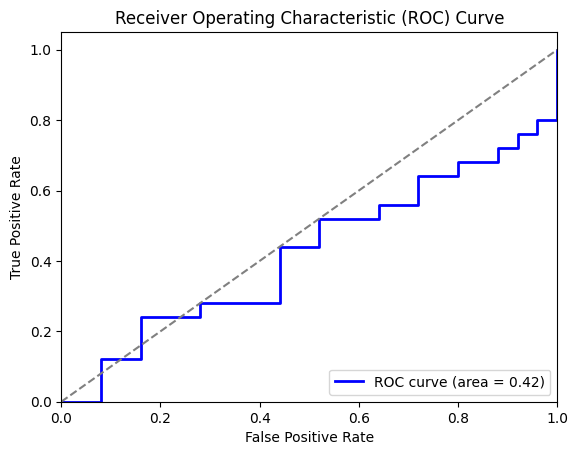

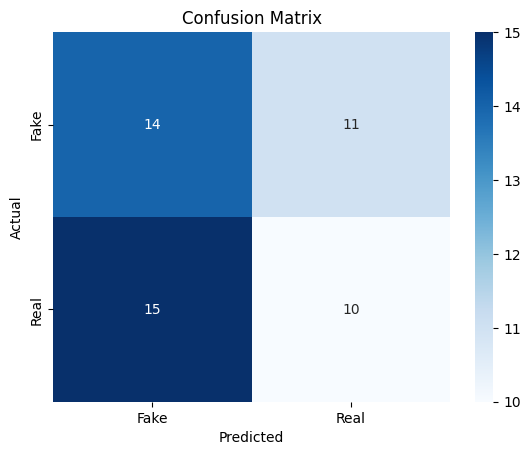

In [ ]:
import torch
import numpy as np
from torch import nn
from tqdm import tqdm  # For progress bar
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# loss function (binary cross-entropy for binary classification)
criterion = nn.CrossEntropyLoss()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

all_preds = []
all_labels = []
all_probs = []  # hold the probabilities for the ROC curve
running_loss = 0.0

with torch.no_grad():  # No need to track gradients for evaluation
    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        loss = criterion(outputs, labels)
        running_loss += loss.item()

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        # Store predictions and labels (for metrics calculation)
        all_preds.append(predicted.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

        # Store predicted probabilities for ROC curve
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy()[:, 1])  # Store probs for class 1 (real/fake)

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
all_probs = np.concatenate(all_probs)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()

# Additional metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv = tp / (tp + fp)
npv = tn / (tn + fn)

# ROC curve and AUC
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Sensitivity (Recall): {sensitivity:.2f}")
print(f"Specificity: {specificity:.2f}")
print(f"Positive Predictive Value (PPV): {ppv:.2f}")
print(f"Negative Predictive Value (NPV): {npv:.2f}")
print(f"Average Loss: {running_loss / len(dataloader):.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

# Plot ROC
import matplotlib.pyplot as plt
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Plot confusion matrix
import seaborn as sns
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


## Specialized DeepFake Model Definition

In [3]:
from timm import create_model
import torch.nn as nn
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class DeepfakeDetectionViT(nn.Module):
    def __init__(self, pretrained=True):
        super(DeepfakeDetectionViT, self).__init__()

        # Load the ViT base model
        self.vit = create_model("vit_base_patch16_224.orig_in21k", pretrained=pretrained)

        num_ftrs = self.vit.num_features

        # Custom fully connected layers for deepfake detection
        self.fc1 = nn.Linear(num_ftrs, 512)  # fully connected layer
        self.fc2 = nn.Linear(512, 2)  # output for real/fake detection (2 classes)
        self.relu = nn.ReLU()  # activation function

    def forward(self, x):
        # Pass through ViT model for feature extraction
        x = self.vit.forward_features(x)

        # Extract the class token (first token)
        x = x[:, 0, :]

        # Pass through the fully connected layers
        x = self.fc1(x)
        x = self.relu(x)  # apply non-linear ReLU activation
        x = self.fc2(x)  # output layer

        return x

In [4]:
# Dataset class to follow PyTorch conventions
class PyTorchDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

## Create and train model with specialized deepfake detection layers on OpenFake

In [ ]:
# Data preparation + augmentation
train_dir = f"{GDRIVE_DATA_DIR}/OpenFake/train"
real_dir = os.path.join(train_dir, 'real')
fake_dir = os.path.join(train_dir, 'fake')

num_images = 4000

real_images = [os.path.join(real_dir, fname) for fname in os.listdir(real_dir) if fname.endswith(('.jpg', '.png', '.jpeg'))]
fake_images = [os.path.join(fake_dir, fname) for fname in os.listdir(fake_dir) if fname.endswith(('.jpg', '.png', '.jpeg'))]

selected_real_images = random.sample(real_images, num_images)
selected_fake_images = random.sample(fake_images, num_images)

# Combine into a list of selected images with labels
selected_images = selected_real_images + selected_fake_images
labels = [0] * num_images + [1] * num_images

In [ ]:
# Image transformations for data preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to match ViT's input size
    transforms.ToTensor(),  # Convert image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize with ImageNet stats
])

# Initialize dataset and dataloaders
dataset = PyTorchDataset(selected_images, labels, transform=transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

In [ ]:
# Instantiate model, set up training device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DeepfakeDetectionViT(pretrained=True).to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# Training loop setup
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device)

        # Zero parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Labels need to be integer class indices (not one-hot encoded)
        labels = labels.long()

        loss = criterion(outputs, labels)

        # Backward pass + optimization
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch + 1}/{epochs}, Loss: {running_loss / len(dataloader):.4f}")


model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

100%|██████████| 500/500 [57:10<00:00,  6.86s/it]


Epoch 1/5, Loss: 0.4734


100%|██████████| 500/500 [05:44<00:00,  1.45it/s]


Epoch 2/5, Loss: 0.2653


...

Epoch 3/5, Loss: 0.1417


100%|██████████| 500/500 [05:46<00:00,  1.44it/s]


Epoch 4/5, Loss: 0.0857


100%|██████████| 500/500 [05:44<00:00,  1.45it/s]

Epoch 5/5, Loss: 0.0632


In [ ]:
# Evaluation loop
model.eval()  # set model to evaluation mode
all_preds = []
all_labels = []
all_probs = []  # store probabilities for the ROC curve

with torch.no_grad():
    running_loss = 0.0
    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item()

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        # Store predictions and labels for metrics calculation
        all_preds.append(predicted.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

        # Store predicted probabilities for ROC curve
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy()[:, 1])


100%|██████████| 500/500 [03:05<00:00,  2.70it/s]


In [ ]:
# Concatenate all predictions and labels
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
all_probs = np.concatenate(all_probs)

# Calculate confusion matrix
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

# Calculate additional metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv = tp / (tp + fp)  # Positive Predictive Value
npv = tn / (tn + fn)  # Negative Predictive Value

In [ ]:
# Print metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Sensitivity (Recall): {sensitivity:.2f}")
print(f"Specificity: {specificity:.2f}")
print(f"Positive Predictive Value (PPV): {ppv:.2f}")
print(f"Negative Predictive Value (NPV): {npv:.2f}")
print(f"Average Loss: {running_loss / len(dataloader):.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

Accuracy: 86.99%
Sensitivity (Recall): 0.74
Specificity: 1.00
Positive Predictive Value (PPV): 1.00
Negative Predictive Value (NPV): 0.79
Average Loss: 0.3320

Classification Report:
              precision    recall  f1-score   support

           0       0.79      1.00      0.88      4000
           1       1.00      0.74      0.85      4000

    accuracy                           0.87      8000
   macro avg       0.90      0.87      0.87      8000
weighted avg       0.90      0.87      0.87      8000



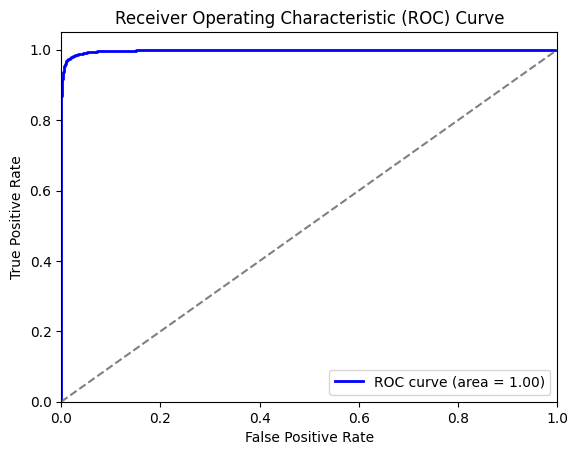

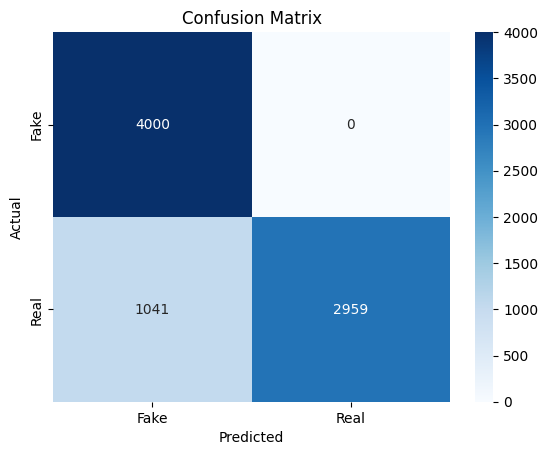

In [ ]:
# Plot ROC curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

Sampling 478 real and 500 fake images from test folders
Test dataset length: 978 samples (batch_size=16)
No checkpoint found at best_wrapped_model.pt; using in-memory model weights
Test samples: 978
Accuracy: 0.6738, AUC: 0.8532
Sensitivity (Recall): 0.3980, Specificity: 0.9623

Classification Report:
               precision    recall  f1-score   support

           0     0.6045    0.9623    0.7425       478
           1     0.9171    0.3980    0.5551       500

    accuracy                         0.6738       978
   macro avg     0.7608    0.6802    0.6488       978
weighted avg     0.7643    0.6738    0.6467       978

Saved predictions CSV to results/test_predictions_sampled_from_train.csv


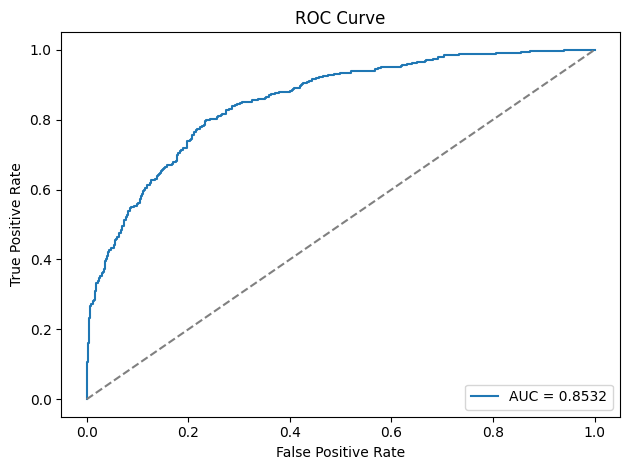

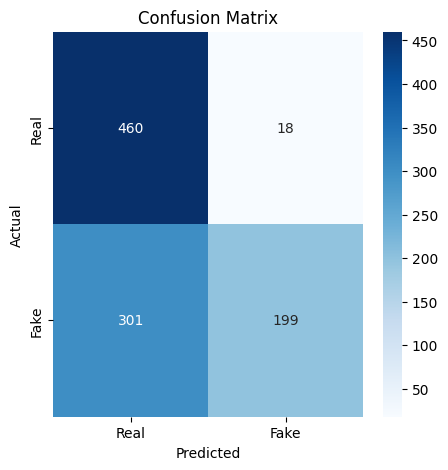

Plots saved: results/roc_curve_sampled_from_train.png results/confusion_matrix_sampled_from_test.png


In [ ]:
# Evaluation helper for test dataset
import os
import torch
import numpy as np
import pandas as pd
import random
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

TEST_DIR = f"{GDRIVE_DATA_DIR}/OpenFake/test"   # sample from test/real and test/fake
SAMPLE_PER_CLASS = 500
checkpoint_path = "best_wrapped_model.pt"
BATCH_SIZE = 16
NUM_WORKERS = 0  # Windows-safe
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUT_DIR = "results"
os.makedirs(OUT_DIR, exist_ok=True)

# Transforms (same as in training)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Collect and sample from test folders
random.seed(42)
real_dir = os.path.join(TEST_DIR, "real")
fake_dir = os.path.join(TEST_DIR, "fake")
real_paths = [os.path.join(real_dir, fn) for fn in os.listdir(real_dir) if fn.lower().endswith(('.jpg', '.jpeg', '.png'))]
fake_paths = [os.path.join(fake_dir, fn) for fn in os.listdir(fake_dir) if fn.lower().endswith(('.jpg', '.jpeg', '.png'))]

if len(real_paths) == 0 or len(fake_paths) == 0:
    raise RuntimeError(f"No images found in {real_dir} or {fake_dir}. Check dataset paths.")

n_real = min(SAMPLE_PER_CLASS, len(real_paths))
n_fake = min(SAMPLE_PER_CLASS, len(fake_paths))
print(f"Sampling {n_real} real and {n_fake} fake images from test folders")

sample_real = random.sample(real_paths, n_real)
sample_fake = random.sample(fake_paths, n_fake)

test_paths = sample_real + sample_fake
test_labels = [0] * len(sample_real) + [1] * len(sample_fake)

# Wrap into dataset
test_dataset = PyTorchDataset(test_paths, test_labels, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=False)

print(f"Test dataset length: {len(test_dataset)} samples (batch_size={BATCH_SIZE})")

# Use existing model object
model = model.to(DEVICE)

if os.path.exists(checkpoint_path):
    state = torch.load(checkpoint_path, map_location=DEVICE)
    # Extract state_dict if present in PyTorch formats
    if isinstance(state, dict):
        if "model_state_dict" in state:
            state_dict = state["model_state_dict"]
        elif "state_dict" in state:
            state_dict = state["state_dict"]
        else:
            state_dict = state

        new_state = {}
        for k, v in state_dict.items():
            nk = k.replace("module.", "") if k.startswith("module.") else k
            new_state[nk] = v
        try:
            model.load_state_dict(new_state, strict=False)
        except Exception as e:
            print("Warning: failed to fully load state_dict into model:", e)
    else:
        try:
            model.load_state_dict(state)
        except Exception as e:
            print("Warning: failed to load checkpoint into model:", e)
    print(f"Loaded checkpoint from {checkpoint_path}")
else:
    print(f"No checkpoint found at {checkpoint_path}; using in-memory model weights")

model.eval()

# Evaluation loop
all_logits = []
all_probs = []
all_preds = []
all_targets = []

softmax = torch.nn.Softmax(dim=1)

with torch.no_grad():
    for batch_imgs, batch_labels in test_loader:
        batch_imgs = batch_imgs.to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)

        logits = model(batch_imgs)
        probs = softmax(logits)
        preds = logits.argmax(dim=1)           #

        all_logits.append(logits.cpu().numpy())
        all_probs.append(probs.cpu().numpy()[:, 1])  # prob for class 1
        all_preds.append(preds.cpu().numpy())
        all_targets.append(batch_labels.cpu().numpy())

if len(all_preds) == 0:
    raise RuntimeError("No batches processed by the DataLoader - check sampled paths exist and transforms succeeded")

all_logits = np.concatenate(all_logits, axis=0)
all_probs = np.concatenate(all_probs, axis=0)
all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

# Metrics
cm = confusion_matrix(all_targets, all_preds)

if cm.size == 4:
    tn, fp, fn, tp = cm.ravel()
else:
    tn = fp = fn = tp = 0

accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp+tn+fp+fn)>0 else 0.0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

fpr, tpr, _ = roc_curve(all_targets, all_probs)
roc_auc = auc(fpr, tpr)

print(f"Test samples: {len(all_targets)}")
print(f"Accuracy: {accuracy:.4f}, AUC: {roc_auc:.4f}")
print(f"Sensitivity (Recall): {sensitivity:.4f}, Specificity: {specificity:.4f}")
print("\nClassification Report:\n", classification_report(all_targets, all_preds, digits=4))

# Save CSV with per-file predictions
df = pd.DataFrame({
    "file": test_paths,
    "target": test_labels,
    "pred": all_preds.tolist(),
    "prob_class1": all_probs.tolist()
})
csv_path = os.path.join(OUT_DIR, "test_predictions_sampled_from_train.csv")
df.to_csv(csv_path, index=False)
print(f"Saved predictions CSV to {csv_path}")

# Plot and save ROC + Confusion Matrix
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
roc_path = os.path.join(OUT_DIR, "roc_curve_sampled_from_train.png")
plt.savefig(roc_path)
plt.show()

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Real","Fake"], yticklabels=["Real","Fake"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
cm_path = os.path.join(OUT_DIR, "confusion_matrix_sampled_from_test.png")
plt.savefig(cm_path)
plt.show()

print("Plots saved:", roc_path, cm_path)


### Save this model

In [ ]:
checkpoint = {
    "model": model.state_dict(),                       # entire model object
    "optimizer_state": optimizer.state_dict(),
    "epoch": epoch
}

torch.save(checkpoint, "/content/drive/MyDrive/DeepfakeDetectionModels/deepfake_vit_checkpoint_modelstate.pth")
print("Saved full model checkpoint.")


Saved full model checkpoint.


## Predict on images outside dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

image_path = list(uploaded.keys())[0]
print("Uploaded:", image_path)


Saving IMG_2511.jpg to IMG_2511.jpg
Uploaded: IMG_2511.jpg


In [ ]:
# Image transformations for data preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to match ViT's input size
    transforms.ToTensor(),  # Convert image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize with ImageNet stats
])

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DeepfakeDetectionViT(pretrained=False)
checkpoint = torch.load("/content/drive/MyDrive/DeepfakeDetectionModels/deepfake_vit_checkpoint_modelstate.pth", map_location=device)
model.load_state_dict(checkpoint["model"])
model.to(device)
model.eval()


DeepfakeDetectionViT(
  (vit): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
      

In [ ]:
from PIL import Image
import torch

def predict_image(model, image_path, transform, device):

    # Load image
    img = Image.open(image_path).convert("RGB")

    # Apply same transforms as training
    tensor = transform(img).unsqueeze(0).to(device)   # shape: [1, 3, H, W]

    # Forward pass
    with torch.no_grad():
        outputs = model(tensor)
        probs = torch.softmax(outputs, dim=1)
        predicted_class = torch.argmax(probs, dim=1).item()

    # Map to class label
    label_map = {0: "REAL", 1: "FAKE"}

    return label_map[predicted_class], probs.cpu().numpy()


In [ ]:
label, probabilities = predict_image(model, image_path, transform, device)

print("Prediction:", label)
print("Class probabilities:", probabilities)


NameError: name 'predict_image' is not defined

In [ ]:
# Evaluation helper for test dataset
import os
import torch
import numpy as np
import pandas as pd
import random
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

TEST_DIR = f"{GDRIVE_DATA_DIR}/wildfake_2k_split/test"   # sample from test/real and test/fake
SAMPLE_PER_CLASS = 500
model_checkpoint_path = "/content/drive/MyDrive/DeepfakeDetectionModels/deepfake_vit_checkpoint_modelstate.pth"
BATCH_SIZE = 16
NUM_WORKERS = 0  # Windows-safe
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUT_DIR = "results"
os.makedirs(OUT_DIR, exist_ok=True)

# Transforms (same as in training)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Collect and sample from test folders
random.seed(42)
real_dir = os.path.join(TEST_DIR, "real")
fake_dir = os.path.join(TEST_DIR, "fake")
real_paths = [os.path.join(real_dir, fn) for fn in os.listdir(real_dir) if fn.lower().endswith(('.jpg', '.jpeg', '.png'))]
fake_paths = [os.path.join(fake_dir, fn) for fn in os.listdir(fake_dir) if fn.lower().endswith(('.jpg', '.jpeg', '.png'))]

if len(real_paths) == 0 or len(fake_paths) == 0:
    raise RuntimeError(f"No images found in {real_dir} or {fake_dir}. Check dataset paths.")

n_real = min(SAMPLE_PER_CLASS, len(real_paths))
n_fake = min(SAMPLE_PER_CLASS, len(fake_paths))
print(f"Sampling {n_real} real and {n_fake} fake images from test folders")

sample_real = random.sample(real_paths, n_real)
sample_fake = random.sample(fake_paths, n_fake)

test_paths = sample_real + sample_fake
test_labels = [0] * len(sample_real) + [1] * len(sample_fake)

# Wrap into dataset
test_dataset = PyTorchDataset(test_paths, test_labels, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=False)

print(f"Test dataset length: {len(test_dataset)} samples (batch_size={BATCH_SIZE})")

# Use existing model object
model = model.to(DEVICE)

if os.path.exists(model_checkpoint_path):
    state = torch.load(model_checkpoint_path, map_location=DEVICE)
    # Extract state_dict if present in PyTorch formats
    if isinstance(state, dict):
        if "model_state_dict" in state:
            state_dict = state["model_state_dict"]
        elif "state_dict" in state:
            state_dict = state["state_dict"]
        else:
            state_dict = state

        new_state = {}
        for k, v in state_dict.items():
            nk = k.replace("module.", "") if k.startswith("module.") else k
            new_state[nk] = v
        try:
            model.load_state_dict(new_state, strict=False)
        except Exception as e:
            print("Warning: failed to fully load state_dict into model:", e)
    else:
        try:
            model.load_state_dict(state)
        except Exception as e:
            print("Warning: failed to load checkpoint into model:", e)
    print(f"Loaded checkpoint from {model_checkpoint_path}")
else:
    print(f"No checkpoint found at {model_checkpoint_path}; using in-memory model weights")

model.eval()

# Evaluation loop
all_logits = []
all_probs = []
all_preds = []
all_targets = []

softmax = torch.nn.Softmax(dim=1)

with torch.no_grad():
    for batch_imgs, batch_labels in test_loader:
        batch_imgs = batch_imgs.to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)

        logits = model(batch_imgs)
        probs = softmax(logits)
        preds = logits.argmax(dim=1)           #

        all_logits.append(logits.cpu().numpy())
        all_probs.append(probs.cpu().numpy()[:, 1])  # prob for class 1
        all_preds.append(preds.cpu().numpy())
        all_targets.append(batch_labels.cpu().numpy())

if len(all_preds) == 0:
    raise RuntimeError("No batches processed by the DataLoader - check sampled paths exist and transforms succeeded")

all_logits = np.concatenate(all_logits, axis=0)
all_probs = np.concatenate(all_probs, axis=0)
all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

# Metrics
cm = confusion_matrix(all_targets, all_preds)

if cm.size == 4:
    tn, fp, fn, tp = cm.ravel()
else:
    tn = fp = fn = tp = 0

accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp+tn+fp+fn)>0 else 0.0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

fpr, tpr, _ = roc_curve(all_targets, all_probs)
roc_auc = auc(fpr, tpr)

print(f"Test samples: {len(all_targets)}")
print(f"Accuracy: {accuracy:.4f}, AUC: {roc_auc:.4f}")
print(f"Sensitivity (Recall): {sensitivity:.4f}, Specificity: {specificity:.4f}")
print("\nClassification Report:\n", classification_report(all_targets, all_preds, digits=4))

# Save CSV with per-file predictions
df = pd.DataFrame({
    "file": test_paths,
    "target": test_labels,
    "pred": all_preds.tolist(),
    "prob_class1": all_probs.tolist()
})
csv_path = os.path.join(OUT_DIR, "test_predictions_sampled_from_train.csv")
df.to_csv(csv_path, index=False)
print(f"Saved predictions CSV to {csv_path}")

# Plot and save ROC + Confusion Matrix
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
roc_path = os.path.join(OUT_DIR, "roc_curve_sampled_from_train.png")
plt.savefig(roc_path)
plt.show()

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Real","Fake"], yticklabels=["Real","Fake"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
cm_path = os.path.join(OUT_DIR, "confusion_matrix_sampled_from_test.png")
plt.savefig(cm_path)
plt.show()

print("Plots saved:", roc_path, cm_path)


Sampling 200 real and 200 fake images from test folders


NameError: name 'PyTorchDataset' is not defined

## Training on WildFake, testing with test set

In [ ]:
# TRAINING
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm

#  existing model checkpoint
model_checkpoint_path = "/content/drive/MyDrive/DeepfakeDetectionModels/deepfake_vit_checkpoint_modelstate.pth"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = DeepfakeDetectionViT(pretrained=False)

# Load  state dict
checkpoint = torch.load(model_checkpoint_path, map_location=device)
if "model" in checkpoint:
    model.load_state_dict(checkpoint["model"])
elif "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.to(device)
model.train()

# Use WildFake this time for additional training
dataset_root = "/content/drive/MyDrive/datasets/wildfake_2k_split"
train_dir = os.path.join(dataset_root, 'train')
real_dir = os.path.join(train_dir, 'real')
fake_dir = os.path.join(train_dir, 'fake')

# image paths
real_images = [os.path.join(real_dir, f) for f in os.listdir(real_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
fake_images = [os.path.join(fake_dir, f) for f in os.listdir(fake_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

print(f"Found {len(real_images)} real and {len(fake_images)} fake images in {train_dir}")

# Combine paths and labels (0=Real, 1=Fake)
all_image_paths = real_images + fake_images
all_labels = [0] * len(real_images) + [1] * len(fake_images)

# Transformations (Same as original training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = PyTorchDataset(all_image_paths, all_labels, transform=transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

criterion = nn.CrossEntropyLoss()
# Really small learning rate to avoid destroying learned features
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

epochs = 5

# Training Loop
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device).long()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        progress_bar.set_postfix({'loss': running_loss / (progress_bar.n + 1)})

    avg_loss = running_loss / len(dataloader)
    print(f"Epoch {epoch + 1} completed. Average Loss: {avg_loss:.4f}")



Found 800 real and 800 fake images in /content/drive/MyDrive/datasets/wildfake_2k_split/train


Epoch 1/5: 100%|██████████| 100/100 [01:02<00:00,  1.61it/s, loss=0.465]


Epoch 1 completed. Average Loss: 0.4646


Epoch 2/5: 100%|██████████| 100/100 [00:59<00:00,  1.69it/s, loss=0.0595]


Epoch 2 completed. Average Loss: 0.0595


...

Epoch 3 completed. Average Loss: 0.0168


Epoch 4/5: 100%|██████████| 100/100 [01:00<00:00,  1.66it/s, loss=0.00586]


Epoch 4 completed. Average Loss: 0.0059


Epoch 5/5: 100%|██████████| 100/100 [01:00<00:00,  1.66it/s, loss=0.00333]

Epoch 5 completed. Average Loss: 0.0033


Evaluating on test set...


100%|██████████| 25/25 [02:43<00:00,  6.53s/it]



Accuracy: 99.00%
ROC AUC: 0.9998

Classification Report:
               precision    recall  f1-score   support

        Real       0.99      0.99      0.99       200
        Fake       0.99      0.99      0.99       200

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



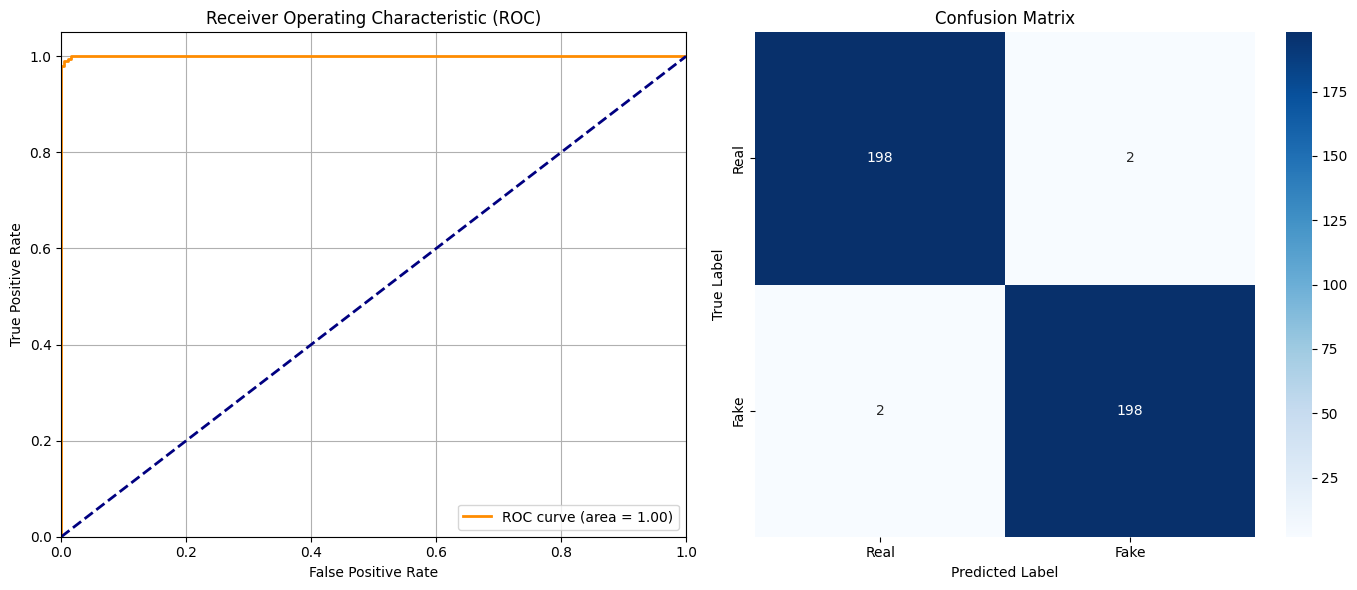

In [ ]:
#TESTING

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, classification_report
import numpy as np

test_dir = os.path.join(dataset_root, 'test')
real_test = os.path.join(test_dir, 'real')
fake_test = os.path.join(test_dir, 'fake')

real_paths_test = [os.path.join(real_test, f) for f in os.listdir(real_test) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
fake_paths_test = [os.path.join(fake_test, f) for f in os.listdir(fake_test) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

# Merge path arrays and assign labels
test_paths = real_paths_test + fake_paths_test
test_labels = [0] * len(real_paths_test) + [1] * len(fake_paths_test)

test_dataset = PyTorchDataset(test_paths, test_labels, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 2. Evaluation Loop
model.eval()
all_probs = []
all_preds = []
all_labels_actual = []

print("Evaluating on test set...")
with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1] # Probability of 'Fake' class
        preds = torch.argmax(outputs, dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels_actual.extend(labels.cpu().numpy())

# 3. Calculate Metrics
acc = accuracy_score(all_labels_actual, all_preds)
cm = confusion_matrix(all_labels_actual, all_preds)
fpr, tpr, thresholds = roc_curve(all_labels_actual, all_probs)
roc_auc = auc(fpr, tpr)

print(f"\nAccuracy: {acc*100:.2f}%")
print(f"ROC AUC: {roc_auc:.4f}")
print("\nClassification Report:\n", classification_report(all_labels_actual, all_preds, target_names=['Real', 'Fake']))

# 4. Plotting
plt.figure(figsize=(14, 6))

# Plot ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)

# Plot Confusion Matrix
plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()

In [ ]:
save_path = "/content/drive/MyDrive/DeepfakeDetectionModels/deepfake_vit_finetuned_wildfake.pth"
torch.save({
    "model": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "epoch": epochs
}, save_path)
print(f"Saved fine-tuned model to {save_path}")

Saved fine-tuned model to /content/drive/MyDrive/DeepfakeDetectionModels/deepfake_vit_finetuned_wildfake.pth


## **Export Model to HuggingFace**

In [ ]:
import os, json, torch

EXPORT_DIR = "/content/drive/MyDrive/DeepfakeDetectionModels/VIT_Transfer"
os.makedirs(EXPORT_DIR, exist_ok=True)

# Save model weights (state_dict)
#torch.save(model.state_dict(), os.path.join(EXPORT_DIR, "deepfake_vit_finetuned_wildfake.pth"))

# Preprocessing details (must match training!)
preprocess = {
    "input_size": 224,
    "interpolation": "bicubic",
    "normalize": {
        "mean": [0.485, 0.456, 0.406],
        "std":  [0.229, 0.224, 0.225]
    }
}

label_map = {"0": "real", "1": "fake"}

config = {
    "name": "vit-base",
    "framework": "pytorch",
    "arch": "vit_base_patch16_224",
    "patch_size": 16,
    "hidden_dim": 768,
    "num_layers": 12,
    "num_heads": 12,
    "num_classes": 2,
    "threshold": 0.50,
    "labels": label_map,
    "notes": "ViT Base transfer learning model for deepfake detection"
}

with open(os.path.join(EXPORT_DIR, "preprocess.json"), "w") as f:
    json.dump(preprocess, f, indent=2)

with open(os.path.join(EXPORT_DIR, "label_map.json"), "w") as f:
    json.dump(label_map, f, indent=2)

with open(os.path.join(EXPORT_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

readme = """---
license: apache-2.0
tags:
  - vision-transformer
  - deepfake-detection
  - image-classification
---

# ViT Base – DeepFakeDetector

Vision Transformer (ViT-B/16) fine-tuned for binary deepfake detection.

## Labels
- 0 = real
- 1 = fake

## Output
- prob_fake ∈ [0,1] (softmax or sigmoid)
"""

with open(os.path.join(EXPORT_DIR, "README.md"), "w") as f:
    f.write(readme)

print("Exported ViT Base artifacts to:", EXPORT_DIR)

Exported ViT Base artifacts to: /content/drive/MyDrive/DeepfakeDetectionModels/VIT_Transfer


In [ ]:
import os
from huggingface_hub import HfApi
from google.colab import userdata


REPO_ID = "DeepFakeDetector/vit-base"
HF_TOKEN = userdata.get('HF_TOKEN_WRITE')

assert HF_TOKEN, "HF_TOKEN_WRITE env var not set."

api = HfApi(token=HF_TOKEN)

# Create repo if it doesn't exist
api.create_repo(repo_id=REPO_ID, repo_type="model", exist_ok=True)

api.upload_folder(
    folder_path=EXPORT_DIR,
    repo_id=REPO_ID,
    repo_type="model",
    commit_message="Upload ViT Base artifacts (weights + configs + preprocess)"
)

print(f"Uploaded to https://huggingface.co/{REPO_ID}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...it_finetuned_wildfake.pth:   0%|          | 1.11MB / 1.03GB            

Uploaded to https://huggingface.co/DeepFakeDetector/vit-base


## **Load Model from Hugging Face**

In [5]:
import torch
import os
from huggingface_hub import snapshot_download

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Download the model from HuggingFace
local_repo = snapshot_download(repo_id="DeepFakeDetector/vit-base", repo_type="model")

# Load the entire checkpoint (which includes optimizer state, epoch, etc.)
checkpoint = torch.load(os.path.join(local_repo, "deepfake_vit_finetuned_wildfake.pth"), map_location="cpu")

# Extract only the model from the checkpoint
state_dict = checkpoint["model"]

model = DeepfakeDetectionViT(pretrained=True).to(device)

# Load the model weights
model.load_state_dict(state_dict)
model.eval()

print("ViT Base weights reloaded successfully from HF")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

ViT Base weights reloaded successfully from HF


## Testing on HuggingFace Manually AI-Generated Datasets
Goal: 100% fake classification

### Load Datasets

In [6]:
!pip install --upgrade huggingface_hub

In [7]:
from huggingface_hub import notebook_login
notebook_login()


In [8]:
import os
from huggingface_hub import snapshot_download


def load_manual_dataset(local_dir="datasets/manual_gen_images"):
    repo_id = "DeepFakeDetector/manual-gen-images"

    print("Downloading dataset")
    dataset_path = snapshot_download(
        repo_id=repo_id,
        repo_type="dataset",
        local_dir=local_dir,
    )

    records = []

    prompts_dir = os.path.join(dataset_path, "prompts")
    images_dir = os.path.join(dataset_path, "images")

    for generator in os.listdir(images_dir):
        generator_path = os.path.join(images_dir, generator)

        if not os.path.isdir(generator_path):
            continue

        for filename in os.listdir(generator_path):
            if not filename.endswith(".png"):
                continue

            prompt_id = filename.replace(".png", "")
            image_path = os.path.join(generator_path, filename)
            prompt_path = os.path.join(prompts_dir, f"{prompt_id}.txt")

            if not os.path.exists(prompt_path):
                continue

            with open(prompt_path, "r", encoding="utf-8") as f:
                prompt_text = f.read().strip()

            records.append({
                "image_path": image_path,
                "generator": generator,
                "prompt_id": prompt_id,
                "prompt_text": prompt_text,
            })

    return records


if __name__ == "__main__":
    dataset = load_manual_dataset()
    print(f"Loaded {len(dataset)} samples")
    print(dataset[0])

Fetching 331 files:   0%|          | 0/331 [00:00<?, ?it/s]

Loaded 200 samples
{'image_path': '/content/datasets/manual_gen_images/images/dalle/p074.png', 'generator': 'dalle', 'prompt_id': 'p074', 'prompt_text': 'Generate a photo of a city block with mixed residential and commercial buildings.'}


### Testing on Datasets

In [9]:
import os
import torch
import numpy as np
import pandas as pd
import random
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def testing_manual_deepfakes(dataset_name):
  TEST_DIR = f"datasets/manual_gen_images/images/{dataset_name}"
  model_checkpoint_path = "/content/drive/MyDrive/DeepfakeDetectionModels/deepfake_vit_finetuned_wildfake.pth"
  BATCH_SIZE = 16
  NUM_WORKERS = 0  # Windows-safe
  DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  OUT_DIR = "results"
  os.makedirs(OUT_DIR, exist_ok=True)

  # Transforms (same as in training)
  test_transform = transforms.Compose([
      transforms.Resize((224, 224)),
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
  ])


  test_paths = [os.path.join(TEST_DIR, fn) for fn in os.listdir(TEST_DIR) if fn.lower().endswith(('.jpg', '.jpeg', '.png'))]

  test_labels = [1] * len(test_paths)

  # Wrap into dataset
  test_dataset = PyTorchDataset(test_paths, test_labels, transform=test_transform)
  test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=False)

  print(f"Test dataset length: {len(test_dataset)} samples (batch_size={BATCH_SIZE})")

  # Evaluation loop
  all_logits = []
  all_probs = []
  all_preds = []
  all_targets = []

  softmax = torch.nn.Softmax(dim=1)

  with torch.no_grad():
      for batch_imgs, batch_labels in test_loader:
          batch_imgs = batch_imgs.to(DEVICE)
          batch_labels = batch_labels.to(DEVICE)

          logits = model(batch_imgs)
          probs = softmax(logits)
          preds = logits.argmax(dim=1)           #

          all_logits.append(logits.cpu().numpy())
          all_probs.append(probs.cpu().numpy()[:, 1])  # prob for class 1
          all_preds.append(preds.cpu().numpy())
          all_targets.append(batch_labels.cpu().numpy())

  if len(all_preds) == 0:
      raise RuntimeError("No batches processed by the DataLoader - check sampled paths exist and transforms succeeded")

  all_logits = np.concatenate(all_logits, axis=0)
  all_probs = np.concatenate(all_probs, axis=0)
  all_preds = np.concatenate(all_preds, axis=0)
  all_targets = np.concatenate(all_targets, axis=0)

  # Metrics
  cm = confusion_matrix(all_targets, all_preds, labels=[0, 1])

  tn, fp, fn, tp = cm.ravel()

  accuracy = (tp + tn) / cm.sum()
  sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
  specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

  if len(np.unique(all_targets)) > 1:
      fpr, tpr, _ = roc_curve(all_targets, all_probs)
      roc_auc = auc(fpr, tpr)
  else:
      fpr, tpr, roc_auc = None, None, float("nan")


  print(f"Test samples: {len(all_targets)}")
  print(f"Accuracy: {accuracy:.4f}, AUC: {roc_auc:.4f}")
  print(f"Sensitivity (Recall): {sensitivity:.4f}, Specificity: {specificity:.4f}")
  print("\nClassification Report:\n", classification_report(all_targets, all_preds, digits=4))

  # Save CSV with per-file predictions
  df = pd.DataFrame({
      "file": test_paths,
      "target": test_labels,
      "pred": all_preds.tolist(),
      "prob_class1": all_probs.tolist()
  })
  csv_path = os.path.join(OUT_DIR, "test_predictions_sampled_from_train.csv")
  df.to_csv(csv_path, index=False)
  print(f"Saved predictions CSV to {csv_path}")

  # Plot and save ROC + Confusion Matrix
  if fpr is not None:

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.tight_layout()
    roc_path = os.path.join(OUT_DIR, "roc_curve_sampled_from_train.png")
    plt.savefig(roc_path)
    plt.show()

  else:
    print("ROC skipped (only one class present).")

  plt.figure(figsize=(5,5))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Real","Fake"], yticklabels=["Real","Fake"])
  plt.ylabel("Actual")
  plt.xlabel("Predicted")
  plt.title("Confusion Matrix")
  cm_path = os.path.join(OUT_DIR, "confusion_matrix_sampled_from_test.png")
  plt.savefig(cm_path)
  plt.show()

  roc_path = "None"

  print("Plots saved:", roc_path, cm_path)


Test dataset length: 100 samples (batch_size=16)
Test samples: 100
Accuracy: 1.0000, AUC: nan
Sensitivity (Recall): 1.0000, Specificity: 0.0000

Classification Report:
               precision    recall  f1-score   support

           1     1.0000    1.0000    1.0000       100

    accuracy                         1.0000       100
   macro avg     1.0000    1.0000    1.0000       100
weighted avg     1.0000    1.0000    1.0000       100

Saved predictions CSV to results/test_predictions_sampled_from_train.csv
ROC skipped (only one class present).


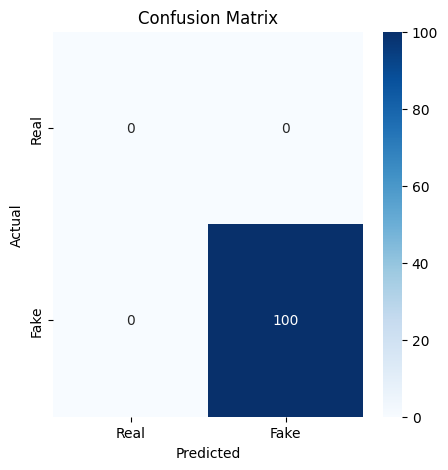

Plots saved: None results/confusion_matrix_sampled_from_test.png


In [10]:
testing_manual_deepfakes("nanobanana")

Test dataset length: 27 samples (batch_size=16)
Test samples: 27
Accuracy: 1.0000, AUC: nan
Sensitivity (Recall): 1.0000, Specificity: 0.0000

Classification Report:
               precision    recall  f1-score   support

           1     1.0000    1.0000    1.0000        27

    accuracy                         1.0000        27
   macro avg     1.0000    1.0000    1.0000        27
weighted avg     1.0000    1.0000    1.0000        27

Saved predictions CSV to results/test_predictions_sampled_from_train.csv
ROC skipped (only one class present).


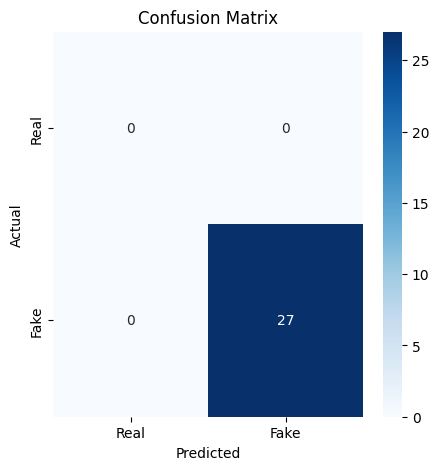

Plots saved: None results/confusion_matrix_sampled_from_test.png


In [11]:
testing_manual_deepfakes("bing")

Test dataset length: 100 samples (batch_size=16)
Test samples: 100
Accuracy: 1.0000, AUC: nan
Sensitivity (Recall): 1.0000, Specificity: 0.0000

Classification Report:
               precision    recall  f1-score   support

           1     1.0000    1.0000    1.0000       100

    accuracy                         1.0000       100
   macro avg     1.0000    1.0000    1.0000       100
weighted avg     1.0000    1.0000    1.0000       100

Saved predictions CSV to results/test_predictions_sampled_from_train.csv
ROC skipped (only one class present).


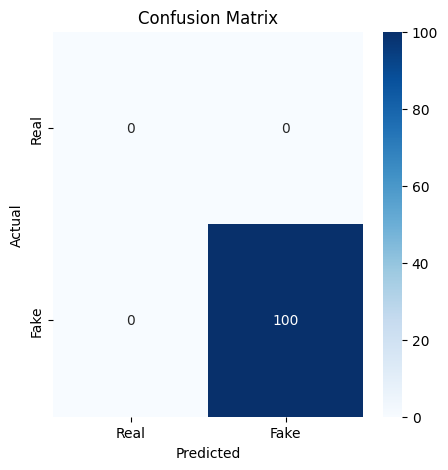

Plots saved: None results/confusion_matrix_sampled_from_test.png


In [12]:
testing_manual_deepfakes("dalle")